In [1]:
library(tidyverse)
library(lme4)
library(lmerTest)
library(emmeans)
library(broom.mixed)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [2]:
# --------------------------------------------------
# Load cagemate-only hierarchy dataframe
# --------------------------------------------------

df <- read_csv(
    
    "C:/Users/sjs93/OneDrive/Documents/GitHub/diff_fam_social_memory_ephys/other_peoples_sutff/sequioa/Phase1_hab_dis_rank_GLM/lfp_kinematics_habit_dishabit_cagemate_rank.csv"
)

# inspect dataframe
glimpse(df)

table(df$condition)

Rows: 148050 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): recording, event, partner, condition, band, metric, region_or_pair...
dbl (19): Unnamed: 0, subject, trial, event_length, distance, velocity_mouse...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 148,050
Columns: 27
$ `Unnamed: 0`             <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,…
$ subject                  <dbl> 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, …
$ recording                <chr> "11_cage_p1_merged.rec", "11_cage_p1_merged.r…
$ event                    <chr> "exp1 sniff", "exp1 sniff", "exp1 sniff", "ex…
$ partner                  <chr> "A", "A", "A", "A", "A", "A", "A", "A", "A", …
$ trial                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ condition                <chr> "cagemate", "cagemate", "cagemate", "cagemate…
$ event_length             <dbl> 3656, 3656, 3656, 3656, 3656, 3656, 3656, 365…
$ distance                 <dbl> 275.7197, 275.7197, 275.7197, 275.7197, 275.7…
$ velocity_mouse1          <dbl> 0.2805405, 0.2805405, 0.2805405, 0.2805405, 0…
$ velocity_mouse2          <dbl> 0.225348, 0.225348, 0.225348, 0.225348, 0.225…
$ moving_angle_mouse1      <dbl> -6.406927, -6.406927, -6.406927, -6.406927, -…
$ moving_angle


cagemate 
  148050 

In [3]:
# --------------------------------------------------
# Keep only coherence rows
# --------------------------------------------------

coh_df <- df |>
    
    filter(metric == "coherence")

In [4]:
# --------------------------------------------------
# Get all unique region pairs
# --------------------------------------------------

region_pairs <- unique(
    coh_df$region_or_pair
)

region_pairs

[1] "mPFC_NAc"  "mPFC_MD"   "mPFC_BLA"  "mPFC_vHPC" "NAc_MD"    "NAc_BLA"  
 [7] "NAc_vHPC"  "MD_BLA"    "MD_vHPC"   "BLA_vHPC"

In [5]:
table(
    coh_df$condition,
    coh_df$relative_rank,
    useNA = "ifany"
)

          
           equal_rank higher_than_subject lower_than_subject
  cagemate       1550               21600              19150

In [6]:
# --------------------------------------------------
# Run mixed-effects models across all region pairs
#
# This loop tests whether coherence differs as a
# function of:
# - relative social hierarchy
# - oscillatory frequency band
# - their interaction
#
# while controlling for:
# - subject movement velocity
# - sniff-event duration
#
# and accounting for repeated sampling within
# recording sessions using a random intercept:
#
#     (1 | recording)
#
# The analysis is repeated separately for each
# inter-regional coherence pair
# (e.g., mPFC_MD, BLA_vHPC, NAc_MD).
#
# For each region pair:
# 1. subset coherence rows
# 2. fit mixed-effects model
# 3. compute Type III ANOVA table
# 4. store results for downstream summaries
# --------------------------------------------------

# get all unique coherence region pairs
region_pairs <- unique(
    coh_df$region_or_pair
)

# initialize empty list to store ANOVA tables
results_list <- list()

# loop through each region pair
for (pair in region_pairs) {

    cat("\n=========================\n")
    cat("Running:", pair, "\n")
    cat("=========================\n")

    # subset dataframe for one region pair
    test_df <- coh_df |>
        
        filter(region_or_pair == pair)

    # fit mixed-effects model
    mixed_model <- lmer(
        
        value ~
            relative_rank * band +
            velocity_mouse1 +
            event_length +
            (1 | recording),

        data = test_df
    )

    # compute Type III ANOVA table
    model_anova <- anova(mixed_model)

    # store ANOVA results
    results_list[[pair]] <- model_anova

    # print ANOVA table to console
    print(model_anova)
}


Running: mPFC_NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        827.0   413.5     2  267.4  2.0359    0.1326    
band               28735.2  7183.8     4 3600.2 35.3702 < 2.2e-16 ***
velocity_mouse1      121.3   121.3     1 3413.2  0.5972    0.4397    
event_length           2.4     2.4     1 3606.0  0.0117    0.9140    
relative_rank:band 11284.1  1410.5     8 3600.2  6.9448 4.074e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       2848.2 1424.11     2   83.6  5.2961  0.006829 ** 
band                1605.2  401.30     4 3404.1  1.4924  0.201697    
velocity_mouse1      165.9  165.94     1 2421.2  0.6171  0.432202    
event_length         825.2  825.23     1 3403.1  3.0689  0.079891 .  
relative_rank:band 12703.5 1587.94     8 3404.1  5.9054 1.561e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_BLA 


...

Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       2892.9 1446.46     2  917.4  7.5265 0.0005726 ***
band                1046.5  261.63     4 3465.2  1.3614 0.2448043    
velocity_mouse1      262.7  262.70     1 3456.0  1.3669 0.2424219    
event_length        1183.1 1183.10     1 3472.5  6.1561 0.0131428 *  
relative_rank:band 10404.2 1300.52     8 3465.2  6.7671 7.668e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: MD_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF   DenDF F value  Pr(>F)   
relative_rank      2050.7 1025.36     2  348.56  3.6506 0.02697 * 
band                869.4  217.35     4 2722.08  0.7738 0.54210   
velocity_mouse1      90.3   90.32     1 2725.85  0.3216 0.57071   
event_length        215.3  215.26     1 2724.08  0.7664 0.38141   
relative_rank:band 7107.2  888.39     8 2722.08  3.1630 0.00143 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: BLA_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       2752.5  1376.3     2   16.5  4.8636 0.0218582 *  
band                3698.2   924.6     4 2448.9  3.2673 0.0110829 *  
velocity_mouse1     3791.5  3791.5     1 1501.2 13.3989 0.0002605 ***
event_length         113.7   113.7     1 2446.3  0.4018 0.5262359    
relative_rank:band 10274.8  1284.3     8 2448.9  4.5388 1.692e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [8]:
region_pairs <- unique(
    coh_df$region_or_pair
)

results_list <- list()

for (pair in region_pairs) {

    cat("\n=========================\n")
    cat("Running:", pair, "\n")
    cat("=========================\n")

    test_df <- coh_df |>
        
        filter(region_or_pair == pair)

    mixed_model <- lmer(
        
        value ~
            relative_rank * band +
            velocity_mouse1 +
            event_length +
            (1 | recording),

        data = test_df
    )

    model_anova <- anova(mixed_model)

    results_list[[pair]] <- model_anova

    print(model_anova)
}


Running: mPFC_NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        827.0   413.5     2  267.4  2.0359    0.1326    
band               28735.2  7183.8     4 3600.2 35.3702 < 2.2e-16 ***
velocity_mouse1      121.3   121.3     1 3413.2  0.5972    0.4397    
event_length           2.4     2.4     1 3606.0  0.0117    0.9140    
relative_rank:band 11284.1  1410.5     8 3600.2  6.9448 4.074e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       2848.2 1424.11     2   83.6  5.2961  0.006829 ** 
band                1605.2  401.30     4 3404.1  1.4924  0.201697    
velocity_mouse1      165.9  165.94     1 2421.2  0.6171  0.432202    
event_length         825.2  825.23     1 3403.1  3.0689  0.079891 .  
relative_rank:band 12703.5 1587.94     8 3404.1  5.9054 1.561e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_BLA 


...

Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       2892.9 1446.46     2  917.4  7.5265 0.0005726 ***
band                1046.5  261.63     4 3465.2  1.3614 0.2448043    
velocity_mouse1      262.7  262.70     1 3456.0  1.3669 0.2424219    
event_length        1183.1 1183.10     1 3472.5  6.1561 0.0131428 *  
relative_rank:band 10404.2 1300.52     8 3465.2  6.7671 7.668e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: MD_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF   DenDF F value  Pr(>F)   
relative_rank      2050.7 1025.36     2  348.56  3.6506 0.02697 * 
band                869.4  217.35     4 2722.08  0.7738 0.54210   
velocity_mouse1      90.3   90.32     1 2725.85  0.3216 0.57071   
event_length        215.3  215.26     1 2724.08  0.7664 0.38141   
relative_rank:band 7107.2  888.39     8 2722.08  3.1630 0.00143 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: BLA_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       2752.5  1376.3     2   16.5  4.8636 0.0218582 *  
band                3698.2   924.6     4 2448.9  3.2673 0.0110829 *  
velocity_mouse1     3791.5  3791.5     1 1501.2 13.3989 0.0002605 ***
event_length         113.7   113.7     1 2446.3  0.4018 0.5262359    
relative_rank:band 10274.8  1284.3     8 2448.9  4.5388 1.692e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [9]:
# --------------------------------------------------
# Extract relative-rank p-values across region pairs
# --------------------------------------------------

summary_df <- tibble()

for (pair in names(results_list)) {

    anova_table <- results_list[[pair]]

    pval <- anova_table[
        "relative_rank",
        "Pr(>F)"
    ]

    summary_df <- bind_rows(
        
        summary_df,
        
        tibble(
            region_pair = pair,
            relative_rank_pvalue = pval
        )
    )
}

summary_df

region_pair,relative_rank_pvalue
<chr>,<dbl>
mPFC_NAc,0.1325871643
mPFC_MD,0.0068294306
mPFC_BLA,0.0286798166
mPFC_vHPC,0.4032169704
NAc_MD,0.0013279887
NAc_BLA,0.6199925285
NAc_vHPC,0.0021157881
MD_BLA,0.0005725606
MD_vHPC,0.0269728767


In [10]:
# --------------------------------------------------
# Create slide-style summary table
# --------------------------------------------------

slide_table <- summary_df |>
    
    arrange(relative_rank_pvalue) |>
    
    mutate(
        
        p_value =
            ifelse(
                relative_rank_pvalue < 0.001,
                "< 0.001",
                round(relative_rank_pvalue, 3)
            )
    ) |>
    
    select(
        region_pair,
        p_value
    )

slide_table

region_pair,p_value
<chr>,<chr>
MD_BLA,< 0.001
NAc_MD,0.001
NAc_vHPC,0.002
mPFC_MD,0.007
BLA_vHPC,0.022
MD_vHPC,0.027
mPFC_BLA,0.029
mPFC_NAc,0.133
mPFC_vHPC,0.403


In [11]:
# --------------------------------------------------
# Keep only significant region pairs
# --------------------------------------------------

slide_table <- summary_df |>
    
    filter(relative_rank_pvalue < 0.05) |>
    
    arrange(relative_rank_pvalue) |>
    
    mutate(
        
        p_value =
            ifelse(
                relative_rank_pvalue < 0.001,
                "< 0.001",
                sprintf("%.3f", relative_rank_pvalue)
            )
    ) |>
    
    select(
        Region_Pair = region_pair,
        p_value
    )

slide_table

Region_Pair,p_value
<chr>,<chr>
MD_BLA,< 0.001
NAc_MD,0.001
NAc_vHPC,0.002
mPFC_MD,0.007
BLA_vHPC,0.022
MD_vHPC,0.027
mPFC_BLA,0.029


In [12]:
# --------------------------------------------------
# Extract p-values across region pairs
# --------------------------------------------------

summary_df <- tibble()

for (pair in names(results_list)) {

    anova_table <- results_list[[pair]]

    # main hierarchy effect
    rank_pval <- anova_table[
        "relative_rank",
        "Pr(>F)"
    ]

    # hierarchy × band interaction
    interaction_pval <- anova_table[
        "relative_rank:band",
        "Pr(>F)"
    ]

    summary_df <- bind_rows(
        
        summary_df,
        
        tibble(
            region_pair = pair,
            relative_rank_pvalue = rank_pval,
            interaction_pvalue = interaction_pval
        )
    )
}

summary_df

region_pair,relative_rank_pvalue,interaction_pvalue
<chr>,<dbl>,<dbl>
mPFC_NAc,0.1325871643,4.073533e-09
mPFC_MD,0.0068294306,1.560741e-07
mPFC_BLA,0.0286798166,2.521678e-12
mPFC_vHPC,0.4032169704,1.462587e-13
NAc_MD,0.0013279887,3.244399e-04
NAc_BLA,0.6199925285,6.938966e-06
NAc_vHPC,0.0021157881,4.904303e-03
MD_BLA,0.0005725606,7.668339e-09
MD_vHPC,0.0269728767,1.429513e-03


In [13]:
# --------------------------------------------------
# Keep only MD_BLA coherence rows
#
# We are now focusing on a single circuit for
# detailed follow-up analysis.
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(region_or_pair == "MD_BLA")

In [14]:
# inspect hierarchy-condition counts

table(test_df$relative_rank)

# inspect frequency-band counts

table(test_df$band)


         equal_rank higher_than_subject  lower_than_subject 
                155                2160                1915 


      Beta      Delta High gamma  Low gamma      Theta 
       846        846        846        846        846 

In [15]:
# --------------------------------------------------
# Fit mixed-effects model
#
# Tests whether MD_BLA coherence differs
# depending on:
# - hierarchy relationship
# - oscillatory frequency band
# - their interaction
#
# while controlling for:
# - movement velocity
# - sniff duration
#
# and accounting for repeated samples
# within recording sessions.
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [16]:
# --------------------------------------------------
# View Type III ANOVA table
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,2892.9197,1446.4599,2,917.445,7.526470,5.725606e-04
band,1046.5316,261.6329,4,3465.157,1.361374,2.448043e-01
velocity_mouse1,262.6994,262.6994,1,3455.975,1.366923,2.424219e-01
event_length,1183.1033,1183.1033,1,3472.508,6.156127,1.314276e-02
relative_rank:band,10404.1674,1300.5209,8,3465.157,6.767095,7.668339e-09


In [17]:
# --------------------------------------------------
# Compute estimated marginal means (EMMs)
#
# Estimates model-predicted coherence values
# for each hierarchy condition within each
# frequency band.
# --------------------------------------------------

emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

emm

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3490' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3490)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3490' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3490)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank           -1.456 4.23 Inf     -9.74     6.826
 higher_than_subject  -9.026 1.86 Inf    -12.67    -5.386
 lower_than_subject   -3.679 1.81 Inf     -7.23    -0.124

band = Delta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank           -2.613 4.23 Inf    -10.89     5.670
 higher_than_subject  -0.864 1.86 Inf     -4.50     2.775
 lower_than_subject   -3.165 1.81 Inf     -6.72     0.391

band = High gamma:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank            4.351 4.23 Inf     -3.93    12.634
 higher_than_subject -11.721 1.86 Inf    -15.36    -8.082
 lower_than_subject   -5.388 1.81 Inf     -8.94    -1.833

band = Low gamma:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank            3.749 4.23 Inf     -4.53    12.032
 higher_than_subject  -9.450 1.86 Inf    -13.09    -5.810
 lower_than_subject   -4.170 1.81 Inf     -7.73    -0.614

band

In [18]:
# --------------------------------------------------
# Pairwise hierarchy comparisons within each band
# --------------------------------------------------

pairs(emm)

band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 equal_rank - higher_than_subject            7.569 4.15 Inf   1.823  0.1619
 equal_rank - lower_than_subject             2.223 3.95 Inf   0.562  0.8402
 higher_than_subject - lower_than_subject   -5.347 1.59 Inf  -3.368  0.0022

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 equal_rank - higher_than_subject           -1.748 4.15 Inf  -0.421  0.9069
 equal_rank - lower_than_subject             0.552 3.95 Inf   0.140  0.9893
 higher_than_subject - lower_than_subject    2.301 1.59 Inf   1.449  0.3158

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 equal_rank - higher_than_subject           16.073 4.15 Inf   3.872  0.0003
 equal_rank - lower_than_subject             9.740 3.95 Inf   2.464  0.0366
 higher_than_subject - lower_than_subject   -6.333 1.59 Inf  -3.989  0.0002

band = Low gamma:
 contrast            

In [19]:
# --------------------------------------------------
# Convert EMM results into dataframe for plotting
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [20]:
# inspect dataframe

head(emm_df)

,relative_rank,band,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,equal_rank,Beta,-1.4564783,4.225716,Inf,-9.738729,6.8257723
2,higher_than_subject,Beta,-9.0259081,1.856918,Inf,-12.665401,-5.3864149
3,lower_than_subject,Beta,-3.6791762,1.814149,Inf,-7.234843,-0.1235091
4,equal_rank,Delta,-2.6127056,4.225716,Inf,-10.894956,5.6695451
5,higher_than_subject,Delta,-0.8642901,1.856918,Inf,-4.503783,2.7752030
6,lower_than_subject,Delta,-3.1649743,1.814149,Inf,-6.720641,0.3906928


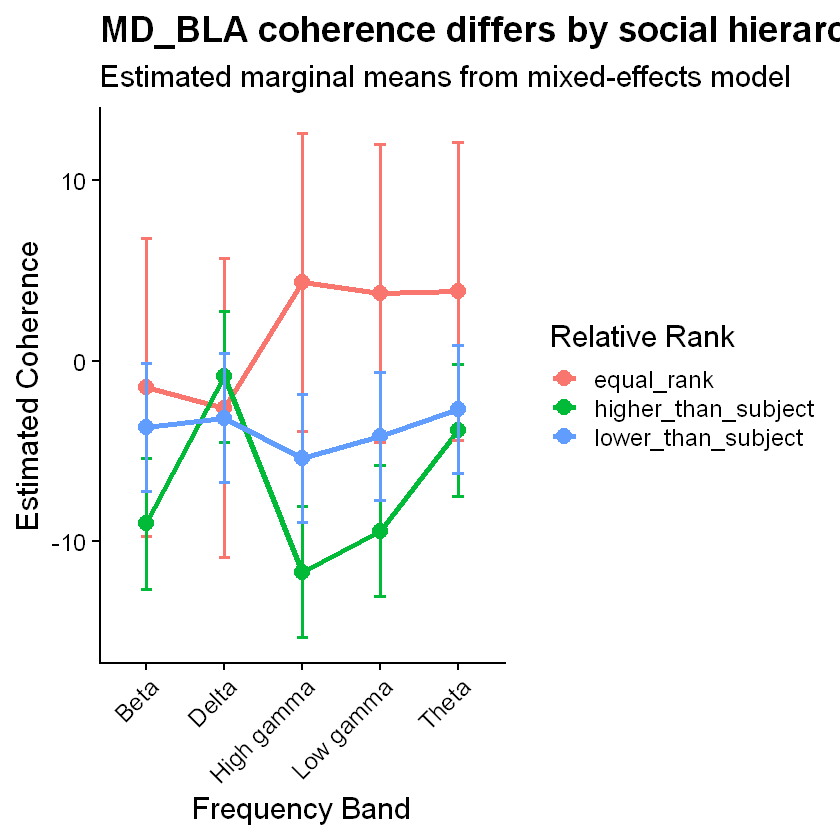

In [21]:
# --------------------------------------------------
# Plot estimated coherence by:
# - frequency band
# - hierarchy relationship
#
# These are model-adjusted means from the
# mixed-effects model.
# --------------------------------------------------

ggplot(
    
    emm_df,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank,
        group = relative_rank
    )
) +

# connect points across bands
geom_line(
    linewidth = 1.5
) +

# mean points
geom_point(
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    width = 0.15,
    linewidth = 1
) +

# labels
labs(
    
    title =
        "MD_BLA coherence differs by social hierarchy relationship",
    
    subtitle =
        "Estimated marginal means from mixed-effects model",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Relative Rank"
) +

# clean theme
theme_classic(
    base_size = 18
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(angle = 45, hjust = 1)
)

In [22]:
# --------------------------------------------------
# Remove equal-rank interactions
#
# Focus analysis on:
# - higher-ranked partner interactions
# - lower-ranked partner interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>
    
    filter(
        relative_rank != "equal_rank"
    )

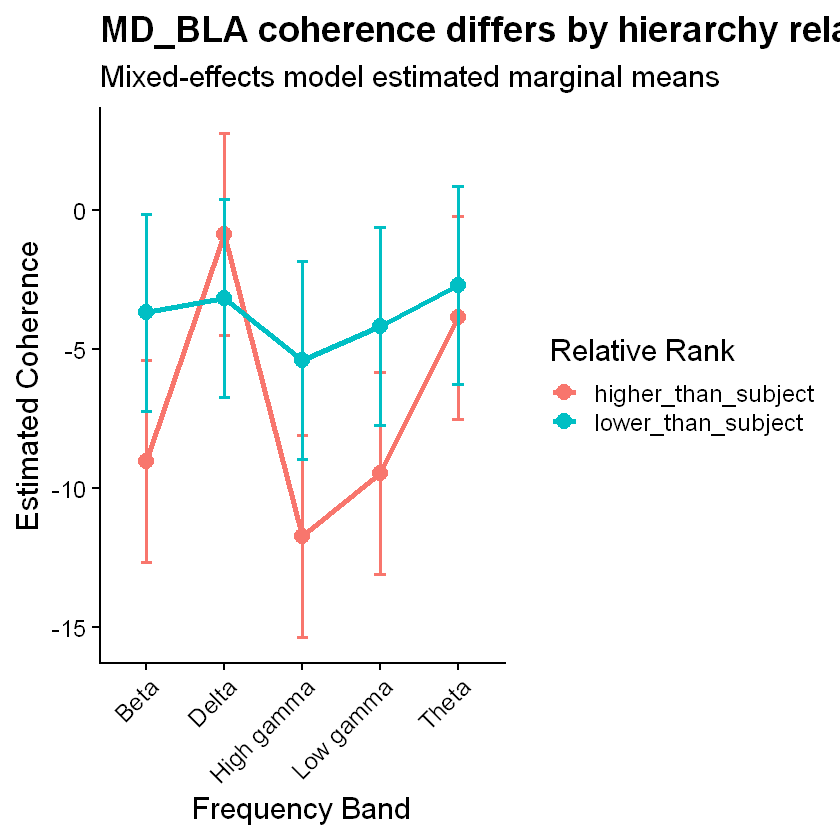

In [23]:
# --------------------------------------------------
# Plot hierarchy-dependent coherence
# after removing equal-rank interactions
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank,
        group = relative_rank
    )
) +

# connect frequency-band estimates
geom_line(
    linewidth = 1.5
) +

# estimated marginal means
geom_point(
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    width = 0.15,
    linewidth = 1
) +

# plot labels
labs(
    
    title =
        "MD_BLA coherence differs by hierarchy relationship",
    
    subtitle =
        "Mixed-effects model estimated marginal means",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Relative Rank"
) +

# clean plotting theme
theme_classic(
    base_size = 18
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(angle = 45, hjust = 1)
)

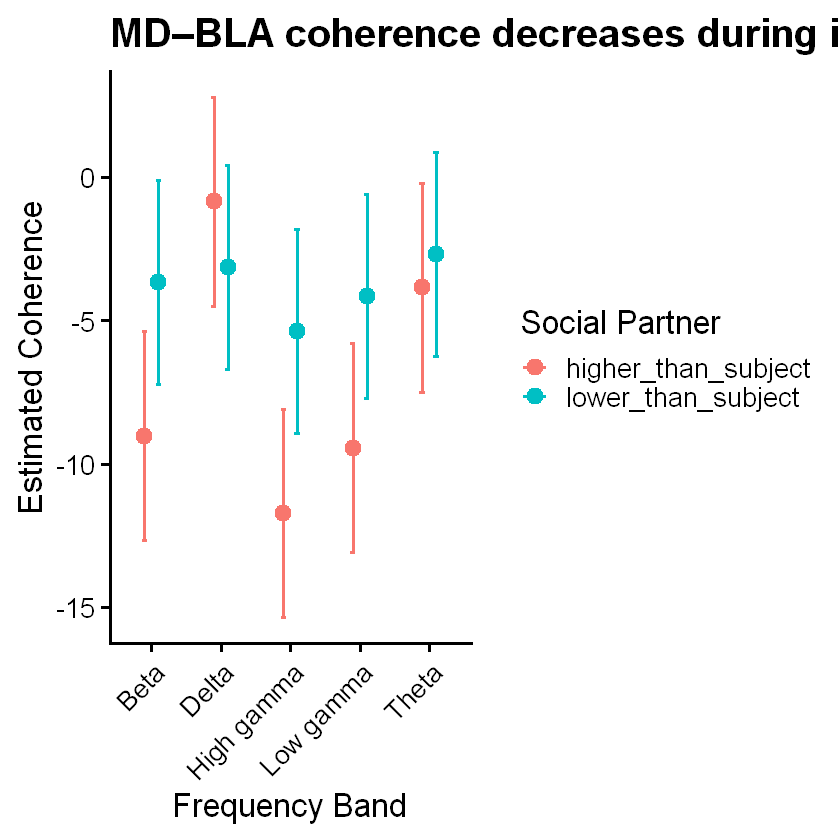

In [24]:
# --------------------------------------------------
# Plot estimated coherence by hierarchy condition
# without connecting lines
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated marginal means
geom_point(
    
    position =
        position_dodge(width = 0.4),
    
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.4),
    
    width = 0.15,
    linewidth = 1
) +

labs(
    
    title =
        "MD–BLA coherence decreases during interactions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Social Partner"
) +

theme_classic(
    base_size = 20
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        )
)

In [25]:
# --------------------------------------------------
# Reorder frequency bands
#
# Plot frequencies from low → high
# for easier biological interpretation
# --------------------------------------------------

emm_df_filtered$band <- factor(
    
    emm_df_filtered$band,
    
    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [26]:
# --------------------------------------------------
# Rename hierarchy labels for cleaner plotting
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(
    
    emm_df_filtered$relative_rank,
    
    "higher_than_subject" =
        "Higher-ranked partner",
    
    "lower_than_subject" =
        "Lower-ranked partner"
)

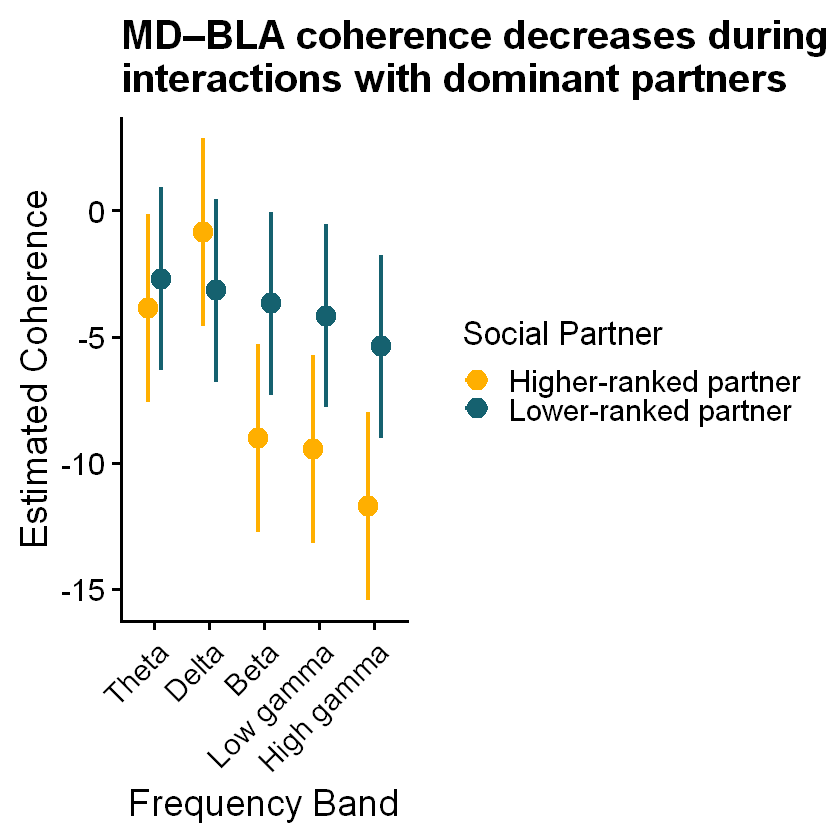

In [27]:
# --------------------------------------------------
# Plot model-estimated coherence values
#
# This visualization shows:
# - mixed-model estimated marginal means
# - confidence intervals
#
# comparing coherence during interactions with:
# - higher-ranked social partners
# - lower-ranked social partners
#
# across oscillatory frequency bands.
# --------------------------------------------------

# --------------------------------------------------
# Plot hierarchy-dependent MD_BLA coherence
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated marginal means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 5
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.2
) +

# custom hierarchy colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "MD–BLA coherence decreases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Social Partner"
) +

# clean theme
theme_classic(
    base_size = 22
) +

theme(
    
    # title formatting
    plot.title =
        element_text(
            face = "bold",
            size = 24
        ),
    
    # axis labels
    axis.title =
        element_text(
            size = 22
        ),
    
    # axis tick labels
    axis.text =
        element_text(
            size = 18,
            color = "black"
        ),
    
    # rotate x labels
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend formatting
    legend.title =
        element_text(
            size = 20
        ),
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # remove top/right borders
    panel.border =
        element_blank()
)

In [28]:
# --------------------------------------------------
# Subset NAc_MD data
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "NAc_MD",
        relative_rank != "equal_rank"
    )

In [29]:
# --------------------------------------------------
# Keep only dominant/subordinate interactions
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "NAc_MD",
        
        relative_rank != "equal_rank"
    )

In [30]:
# --------------------------------------------------
# Fit NAc_MD mixed model
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [31]:
# --------------------------------------------------
# Type III ANOVA
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,1812.0053,1812.0053,1,724.8066,11.107304,9.035487e-04
band,16148.2689,4037.0672,4,3515.1054,24.746580,3.118103e-20
velocity_mouse1,424.3870,424.3870,1,3521.4582,2.601425,1.068573e-01
event_length,502.0453,502.0453,1,3521.1028,3.077458,7.947149e-02
relative_rank:band,3316.0799,829.0200,4,3515.1054,5.081761,4.408332e-04


In [32]:
# --------------------------------------------------
# Compute NEW estimated marginal means
# --------------------------------------------------

emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3535' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3535)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3535' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3535)' or larger];
but be warned that this may result in large computation time and memory use.



In [33]:
# --------------------------------------------------
# Convert emmeans to dataframe
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [34]:
emm_df

,relative_rank,band,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,higher_than_subject,Beta,-5.6488857,1.914781,Inf,-9.401788,-1.8959830
2,lower_than_subject,Beta,0.3391814,1.985182,Inf,-3.551703,4.2300658
3,higher_than_subject,Delta,0.7511133,1.914781,Inf,-3.001789,4.5040159
4,lower_than_subject,Delta,1.2811389,1.985182,Inf,-2.609745,5.1720232
5,higher_than_subject,High gamma,-8.1657501,1.914781,Inf,-11.918653,-4.4128475
6,lower_than_subject,High gamma,-2.9982806,1.985182,Inf,-6.889165,0.8926038
7,higher_than_subject,Low gamma,-5.2335079,1.914781,Inf,-8.986411,-1.4806053
8,lower_than_subject,Low gamma,-1.9329988,1.985182,Inf,-5.823883,1.9578855
9,higher_than_subject,Theta,-5.0693696,1.914781,Inf,-8.822272,-1.3164670


In [35]:
# --------------------------------------------------
# Pairwise hierarchy comparisons within each band
# --------------------------------------------------

pairs(emm)

band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -5.99 1.48 Inf  -4.058 <0.0001

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -0.53 1.48 Inf  -0.359  0.7194

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -5.17 1.48 Inf  -3.502  0.0005

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -3.30 1.48 Inf  -2.237  0.0253

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -4.99 1.48 Inf  -3.380  0.0007

Degrees-of-freedom method: asymptotic 

In [36]:
# --------------------------------------------------
# Remove equal-rank interactions
#
# Focus only on:
# - higher-ranked partner interactions
# - lower-ranked partner interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>
    
    filter(
        relative_rank != "equal_rank"
    )

In [37]:
# --------------------------------------------------
# Reorder frequency bands
# --------------------------------------------------

emm_df_filtered$band <- factor(
    
    emm_df_filtered$band,
    
    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [38]:
# --------------------------------------------------
# Rename hierarchy labels
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(
    
    emm_df_filtered$relative_rank,
    
    "higher_than_subject" =
        "Higher-ranked partner",
    
    "lower_than_subject" =
        "Lower-ranked partner"
)

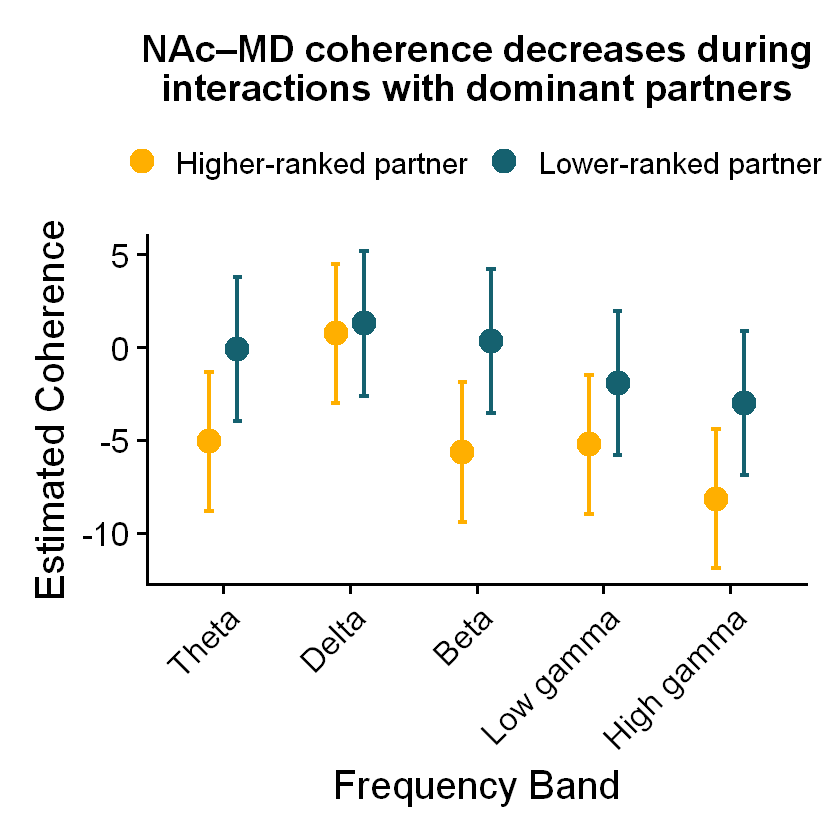

In [39]:
# --------------------------------------------------
# Create publication-style hierarchy coherence plot
# --------------------------------------------------

p <- ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 6
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.4
) +

# custom colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "NAc–MD coherence decreases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = NULL
) +

# cleaner theme
theme_classic(
    base_size = 24
) +

theme(
    
    # centered title
    plot.title =
        element_text(
            face = "bold",
            size = 22,
            hjust = 0.5
        ),
    
    # axis titles
    axis.title =
        element_text(
            size = 24
        ),
    
    # tick labels
    axis.text =
        element_text(
            size = 20,
            color = "black"
        ),
    
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend on top
    legend.position = "top",
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # spacing
    plot.margin =
        margin(20,20,20,20)
)

p

In [40]:
# --------------------------------------------------
# Subset MD_vHPC data
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "MD_vHPC",
        
        relative_rank != "equal_rank"
    )

In [41]:
# --------------------------------------------------
# Fit mixed model
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [42]:
# --------------------------------------------------
# Type III ANOVA
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,1394.0905,1394.0905,1,121.2194,4.9530243,2.789422e-02
band,6894.7912,1723.6978,4,2702.0783,6.1240769,6.655709e-05
velocity_mouse1,121.2993,121.2993,1,2705.7855,0.4309607,5.115737e-01
event_length,155.9277,155.9277,1,2704.1804,0.5539912,4.567561e-01
relative_rank:band,4975.2315,1243.8079,4,2702.0783,4.4190896,1.460493e-03


In [43]:
emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

pairs(emm)

band = Beta:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     3.71 3.57 162   1.041  0.2994

band = Delta:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject    10.32 3.57 162   2.893  0.0043

band = High gamma:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     3.84 3.57 162   1.078  0.2828

band = Low gamma:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     8.70 3.57 162   2.441  0.0157

band = Theta:
 contrast                                 estimate   SE  df t.ratio p.value
 higher_than_subject - lower_than_subject     8.40 3.57 162   2.355  0.0197

Degrees-of-freedom method: kenward-roger 

In [44]:
# --------------------------------------------------
# Convert emmeans to dataframe
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [45]:
# --------------------------------------------------
# Remove equal-rank interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>

    filter(
        relative_rank != "equal_rank"
    )

In [46]:
# --------------------------------------------------
# Reorder frequency bands
# --------------------------------------------------

emm_df_filtered$band <- factor(

    emm_df_filtered$band,

    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [47]:
# --------------------------------------------------
# Rename hierarchy labels
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(

    emm_df_filtered$relative_rank,

    "higher_than_subject" =
        "Higher-ranked partner",

    "lower_than_subject" =
        "Lower-ranked partner"
)

In [50]:
colnames(emm_df_filtered)

[1] "relative_rank" "band"          "emmean"        "SE"           
[5] "df"            "lower.CL"      "upper.CL"

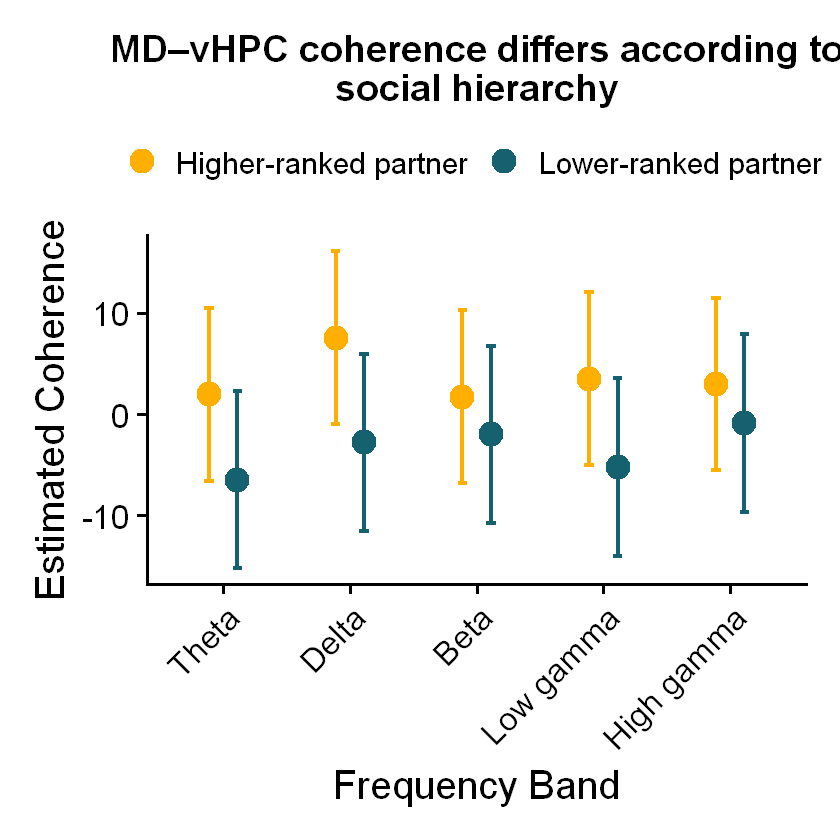

In [53]:
# --------------------------------------------------
# Create publication-style hierarchy coherence plot
# --------------------------------------------------

p <- ggplot(

    emm_df_filtered,

    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated means
geom_point(

    position =
        position_dodge(width = 0.45),

    size = 6
) +

# confidence intervals
geom_errorbar(

    aes(
        ymin = lower.CL,
        ymax = upper.CL
    ),

    position =
        position_dodge(width = 0.45),

    width = 0.15,

    linewidth = 1.4
) +

# custom colors
scale_color_manual(

    values = c(

        "Higher-ranked partner" = "#ffaf00",

        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(

    title =
        "MD–vHPC coherence differs according to\nsocial hierarchy",

    x = "Frequency Band",

    y = "Estimated Coherence",

    color = NULL
) +

# cleaner theme
theme_classic(
    base_size = 24
) +

theme(

    plot.title =
        element_text(
            face = "bold",
            size = 22,
            hjust = 0.5
        ),

    axis.title =
        element_text(
            size = 24
        ),

    axis.text =
        element_text(
            size = 20,
            color = "black"
        ),

    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),

    legend.position = "top",

    legend.text =
        element_text(
            size = 18
        ),

    plot.margin =
        margin(20,20,20,20)
)

p

In [49]:
test_df <- coh_df |>

    filter(
        region_or_pair == "mPFC_MD",
        relative_rank != "equal_rank"
    )

model <- lmer(

    value ~

        relative_rank * band +

        velocity_mouse1 +

        event_length +

        (1 | recording),

    data = test_df
)

emm <- emmeans(
    model,
    ~ relative_rank | band
)

pairs(emm)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3365' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3365)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3365' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3365)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    1.989 1.67 Inf   1.192  0.2332

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    8.222 1.67 Inf   4.928 <0.0001

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject   -2.289 1.67 Inf  -1.372  0.1700

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    2.393 1.67 Inf   1.434  0.1515

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject   -0.688 1.67 Inf  -0.412  0.6800

Degrees-of-freedom method: asymptotic 